playground is to work on current issues with newest version of 2d_combined_playground.py

current issues:
- traditional spec image looks really weird when testing in .py file
- optional show_grid not working

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import utils
import new_utils
import prep_utils
import plot_funcs
import helper_utils

In [2]:
H_SHEET = "h test.xlsx"
HE_SHEET = "he test.xlsx"
NIST_SHEET = "oxygen nist 2.xlsx"
H_DF = pd.read_excel(H_SHEET)
HE_DF = pd.read_excel(HE_SHEET)
NIST_DF = pd.read_excel(NIST_SHEET)
global df  
df = NIST_DF

In [3]:
def trad_spec(data_df, fig_size=utils.FIG_SIZE, dpi=utils.DPI,):

    df_plot_data, should_exit_early, has_any_nist = prep_utils.prep_with_nist(data_df = data_df)
    if should_exit_early:
        fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
        ax.set_axis_off()
        print("Ending Rendering Early.")
        return fig

    fig, ax = plot_funcs.plot(df_plot_data = df_plot_data, nm_col = helper_utils.wl_col, has_any_nist=has_any_nist)
    return fig

In [4]:
def plot_other_spec(data_df):
    helper_utils.get_graph_type()

    if helper_utils.graph_type == 'traditional':
        trad_spec(data_df=data_df)
    
    else:
        new_utils.scale_by_int()
        data_df, should_exit_early = prep_utils.prep_other(data_df = data_df)
        if should_exit_early:
            fig, ax = plt.subplots(figsize=new_utils.fig_size, dpi=utils.DPI)
            ax.set_axis_off()
            print("Ending Rendering Early.")
            return fig
        new_utils.axis_labels()

        if helper_utils.graph_type == 'bar':
            plot_funcs.bar_iteration(data_df = data_df)
            plt.title("Bar Chart", color = new_utils.colour)    # want bar title to be "Bar Chart", rest are set to "Plot". have to figure out how to make that conditional.
        elif helper_utils.graph_type == 'scatter':
            plot_funcs.scatter_iteration(data_df = data_df)
        elif helper_utils.graph_type == 'gaussian':
            plot_funcs.gaussian_iteration(df_plot_data= data_df)
        elif helper_utils.graph_type == 'line':
            plot_funcs.line_plot_iteration(data_df=data_df)
        elif helper_utils.graph_type == 'smoothed line':
            plot_funcs.filled_plot(data_df = data_df)
        elif helper_utils.graph_type == 'filled line':
            plot_funcs.filled_plot(data_df = data_df)


In [5]:
def detect_prep(data_df, force_nist = None):
    df_data, has_any_nist = prep_utils.run_nist_check(data_df=data_df, force_nist=force_nist)

    if has_any_nist is True:
        prep_type = 'nist'
        nist_plot_type = input("NIST Descriptors Detected. Choose NIST Graph Type: Gaussian or Traditional").lower()
        if nist_plot_type == 'gaussian' or nist_plot_type == 'g':
            helper_utils.graph_type = 'gaussian'
            new_utils.axis_labels()
            plot_funcs.gaussian_iteration(df_plot_data = df_data)
        if nist_plot_type == 'traditional' or nist_plot_type == 'trad' or nist_plot_type == 't':
            helper_utils.graph_type = 'traditional'
            trad_spec(data_df = df_data)
    else:
        prep_type = 'generic'
        plot_other_spec(data_df=df_data)
    
    return prep_type, helper_utils.graph_type


Scale brightness: Yes
(prep_other) ymax =  206.0
None
n
(set_y_lim) 250


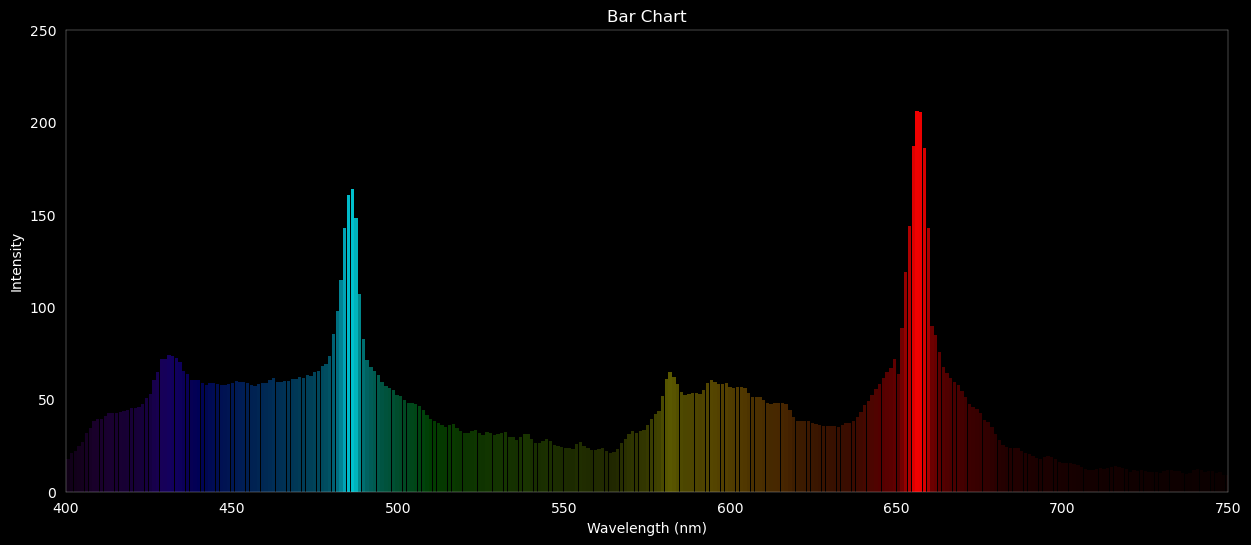

In [6]:
detect_prep(H_DF)
plt.show()

In [7]:
#detect_prep(H_DF)